In [1]:
import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from utils import Extractor
from circle_fit import taubinSVD
from paddleocr import PaddleOCR

In [2]:
ppocr = PaddleOCR(det_model_dir='ppocr/ch_PP-OCRv3_det_infer',
                rec_model_dir='ppocr/ch_PP-OCRv3_rec_infer',
                cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/16 07:55:28] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='ppocr/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, fourie

In [3]:
extractor = Extractor()
extractor.load_model()

# GG Home Mini 1

In [22]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img_org = cv2.imread('img.jpg')

mask = extractor.get_mask(img_org)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img_org.shape)
print("mask shape:",mask.shape)

img shape: (3684, 4912, 3)
mask shape: (3104, 4192)


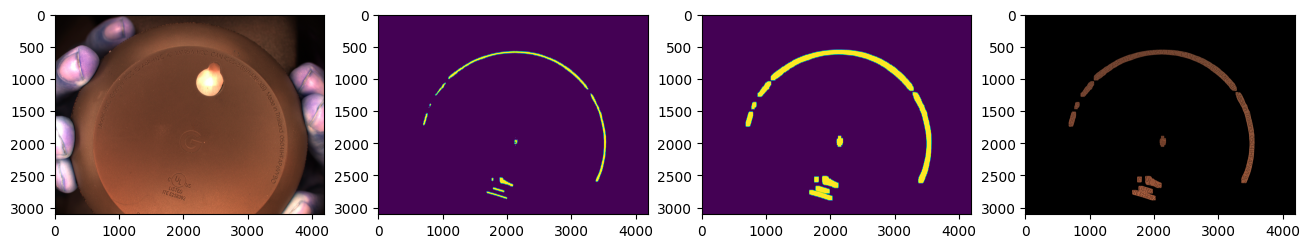

In [23]:
img_resize = cv2.resize(img_org,(mask.shape[1],mask.shape[0]))
img = img_resize.copy()

# and mask
res = cv2.bitwise_and(img,img,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

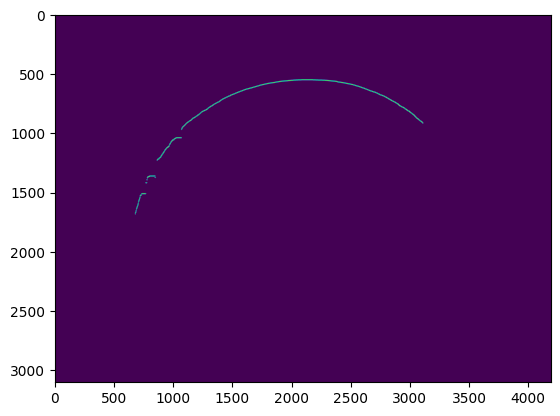

In [24]:
w,h = dilate.shape

v_lines = []
c = []
for i in range(w):
    v_line = dilate[:,i:i+1]
    pos = cv2.findNonZero(v_line) #x,y
    if pos is not None:
        c.append((i,pos[0][0][-1]))
    v_lines.append(v_line)
    
blank = np.zeros_like(dilate)
for p in c:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

xc=2121, yc=2026, r=1480, sigma=7.854355631297974


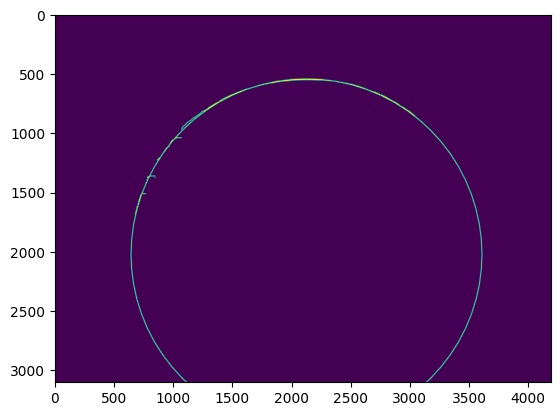

In [25]:
xc, yc, r, sigma = taubinSVD(c)
r = int(r)
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

cv2.circle(blank,(int(xc),int(yc)),int(r),(255),6)
plt.imshow(blank)

(765, 1515)
(847, 1378)


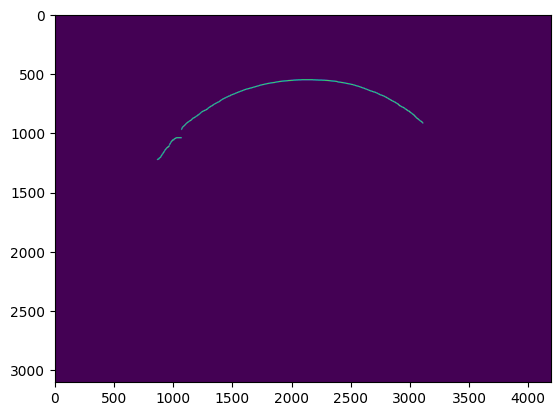

In [21]:
C= []
c_sub = []
p0 = c[0]
DMAX = 80
for i in range(len(c)):
    p = c[i]
    c_sub.append(p)
    d = cv2.norm(np.array(p),np.array(p0))
    if d > DMAX:
        C.append(c_sub)
        c_sub = []
        print(p0)
    p0 = p
    
C.append(c_sub) # the final c_sub is your circle

L = [len(i) for i in C]
c_sub = C[np.argmax(L)]

blank = np.zeros_like(dilate)
for p in c_sub:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

xc=2121, yc=2046, r=1548, sigma=6.2724825834128275


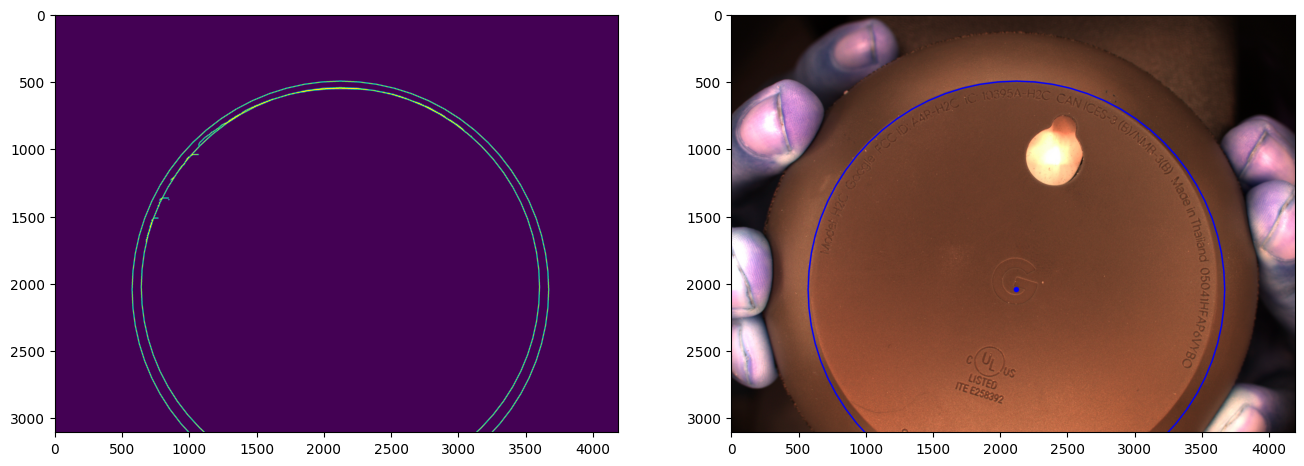

In [26]:
xc, yc, r, sigma = taubinSVD(c_sub)
r = int(r) +50
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

cv2.circle(blank,(int(xc),int(yc)),int(r),(255),6)
cv2.circle(img,(int(xc),int(yc)),20,(0,0,255),-1)
cv2.circle(img,(int(xc),int(yc)),r,(0,0,255),10)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,10))
axes[0].imshow(blank)
axes[1].imshow(img)

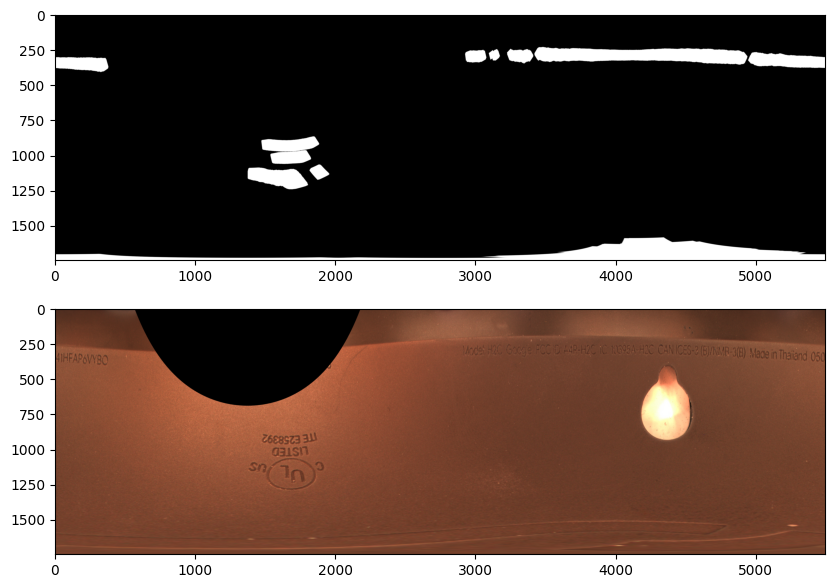

In [27]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR

merged = cv2.merge([dilate,dilate,dilate])
merged = merged*255

x = int(xc)
y = int(yc)
R = r+ 200 #200

polar_mask = cv2.warpPolar(merged,(0,0),(x,y),R,flags)
polar_mask = polar_mask.transpose(1,0,2)[::-1]
polar_img = cv2.warpPolar(img_resize,(0,0),(x,y),R,flags)
polar_img = polar_img.transpose(1,0,2)[::-1]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,7))
axes[0].imshow(polar_mask)
axes[1].imshow(polar_img)

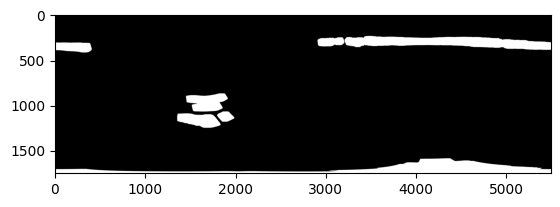

In [28]:
k = 5
kernel = np.ones((k,k*10),np.uint8)
polar_dilate = cv2.dilate(polar_mask,kernel,iterations=1)
plt.imshow(polar_dilate)

7


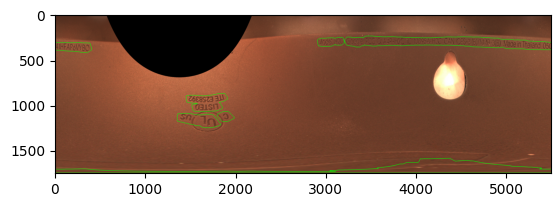

In [29]:
# find contour
gray = cv2.cvtColor(polar_dilate, cv2.COLOR_BGR2GRAY) # polar_mask
ret, thresh = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours))
polar_copy = polar_img.copy()
cv2.drawContours(polar_copy, contours, -1, (0,255,0), 3)
plt.imshow(polar_copy)

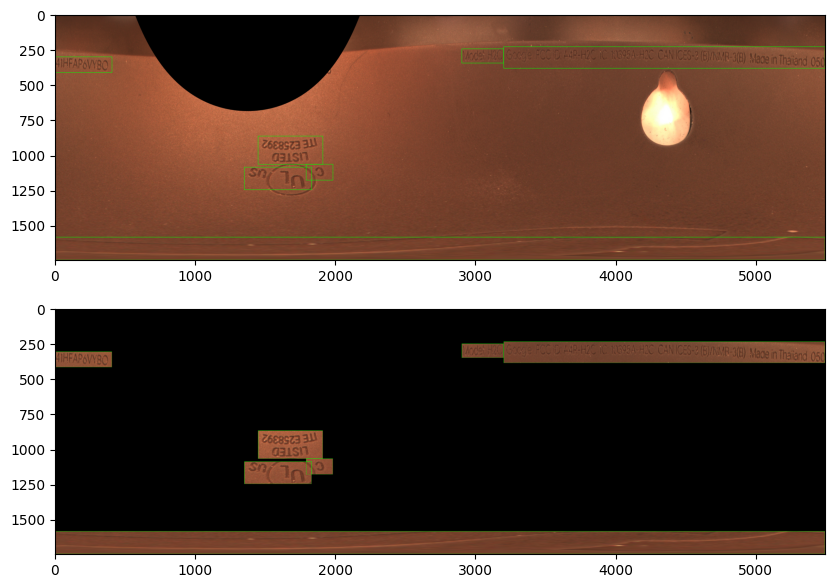

In [30]:
blank = np.zeros_like(polar_img)
img = polar_img.copy()
for i,cnt in enumerate(contours):
    rect = cv2.minAreaRect(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
    roi = img[y:y+h,x:x+w]
    blank[y:y+h,x:x+w] = img[y:y+h,x:x+w]

cv2.imwrite('rec.jpg',img)
cv2.imwrite('mask.jpg',blank)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,7))
axes[0].imshow(img)
axes[1].imshow(blank)

[2023/01/16 08:10:14] ppocr DEBUG: dt_boxes num : 5, elapse : 0.2223341464996338
[2023/01/16 08:10:15] ppocr DEBUG: rec_res num  : 5, elapse : 0.5494143962860107
PPOCR:
[[[[[3371.0, 234.0], [5481.0, 268.0], [5479.0, 383.0], [3369.0, 349.0]], ('eFCCID:A4R-H2C iC 10395A-H2C CANICES-3(B)/NMB-3(B) Madein Thaiand 050', 0.8999072313308716)], [[[11.0, 317.0], [395.0, 317.0], [395.0, 410.0], [11.0, 410.0]], ('41HFAP6VYBO', 0.9499461650848389)]]] 



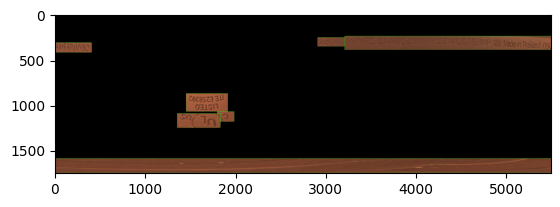

In [31]:
im = blank #img

res1 = ppocr.ocr(im,det=True,rec=True,cls=False)
print("PPOCR:")
print(res1,"\n")

plt.imshow(im)

In [32]:
t = ""
for r in res1[0]:
    if r[1][1] > 0.8:
        print(r)
        t+=r[1][0]

print(t)

[[[3371.0, 234.0], [5481.0, 268.0], [5479.0, 383.0], [3369.0, 349.0]], ('eFCCID:A4R-H2C iC 10395A-H2C CANICES-3(B)/NMB-3(B) Madein Thaiand 050', 0.8999072313308716)]
[[[11.0, 317.0], [395.0, 317.0], [395.0, 410.0], [11.0, 410.0]], ('41HFAP6VYBO', 0.9499461650848389)]
eFCCID:A4R-H2C iC 10395A-H2C CANICES-3(B)/NMB-3(B) Madein Thaiand 05041HFAP6VYBO


In [33]:
model = None
serial = None

print(t)
t=t.lower()
# infer model
count = t.count('h2c')
if count > 1:
    model = 'H2C'
# infer serial 14 digit
if len(t)>14:
    for i in range(len(t)):
        s = t[i:i+14]
        if len(s) == 14\
            and all([c.isalnum() for c in s])\
            and all([c.isnumeric() for c in s[:4]]):
            print('serial: ',s)
            serial = s
            
print(model.upper(),serial.upper())

eFCCID:A4R-H2C iC 10395A-H2C CANICES-3(B)/NMB-3(B) Madein Thaiand 05041HFAP6VYBO
serial:  05041hfap6vybo
H2C 05041HFAP6VYBO


# GG Home Mini 2

img shape: (3684, 4912, 3)
mask shape: (3104, 4192)


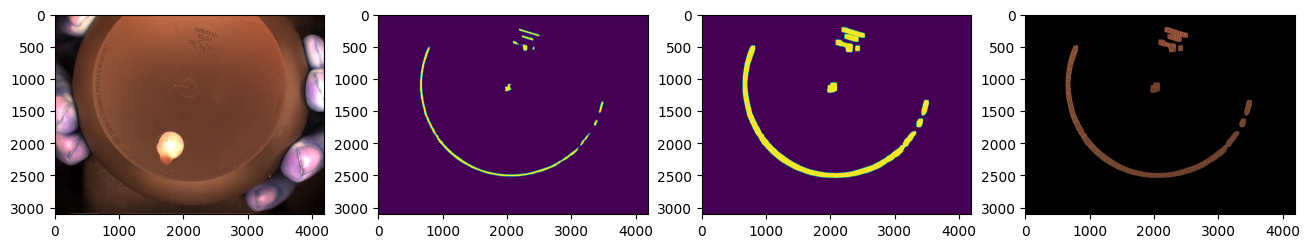

In [9]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img_org = cv2.imread('img2.jpg')

mask = extractor.get_mask(img_org)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img_org.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img_org,(mask.shape[1],mask.shape[0]))
img = img_resize.copy()

# and mask
res = cv2.bitwise_and(img,img,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

# GG Home Mini 3

img shape: (4912, 3684, 3)
mask shape: (3104, 4192)


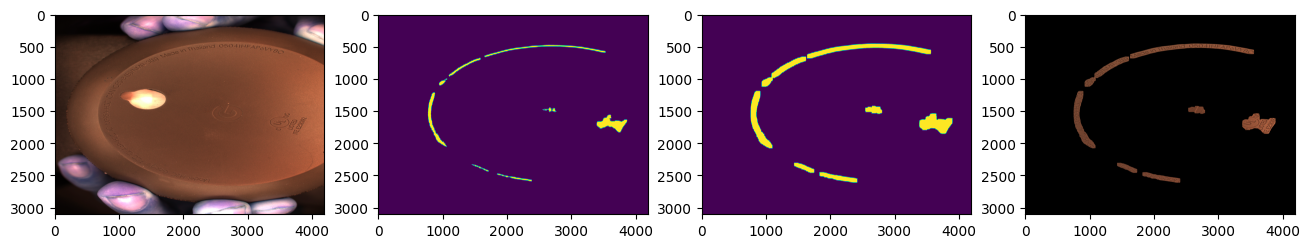

In [10]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img_org = cv2.imread('img3.jpg')

mask = extractor.get_mask(img_org)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img_org.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img_org,(mask.shape[1],mask.shape[0]))
img = img_resize.copy()

# and mask
res = cv2.bitwise_and(img,img,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

# GG Home Mini 4

img shape: (4912, 3684, 3)
mask shape: (3104, 4192)


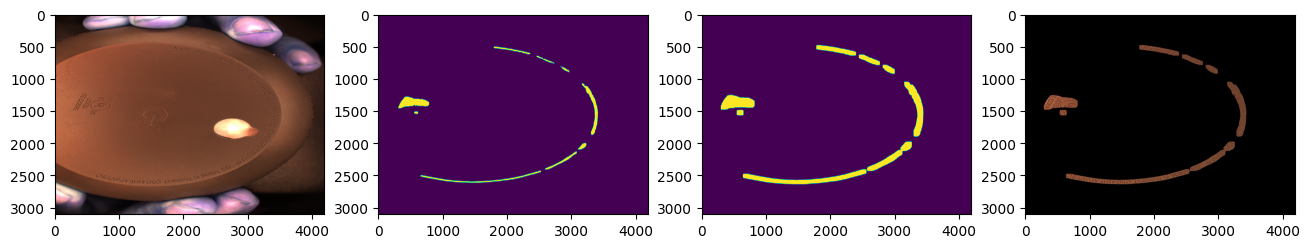

In [11]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img_org = cv2.imread('img4.jpg')

mask = extractor.get_mask(img_org)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img_org.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img_org,(mask.shape[1],mask.shape[0]))
img = img_resize.copy()

# and mask
res = cv2.bitwise_and(img,img,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)